In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import umap
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import commons, models, utils, losses, lightning_wrapper
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDiseaseBinaryBatchSampler

from s3prl.upstream.mockingjay.builder import PretrainedTransformer
from s3prl.upstream.mockingjay.model import TransformerSpecPredictionHead
from IPython.display import Audio

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_1443891/1599875024.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
sample_rate = 16000
"""
For feature == 'fbank' or 'mfcc'
"""
num_mels = 80 # int, dimension of feature
num_mfcc = 13 # int, number of MFCCs
window_size = 25 # int, window size for FFT (ms)
stride = 10 # int, window stride for FFT
"""
For feature == 'mel' or 'linear'
"""
num_freq = 1025
frame_length_ms = 50
frame_shift_ms = 12.5
preemphasis = 0.97
min_level_db = -100
ref_level_db = 20
hop_length = 250
griffin_lim_iters = 16
power = 1.5 # Power to raise magnitudes to prior to Griffin-Lim

def _stft_parameters(sample_rate):
    n_fft = (num_freq - 1) * 2
    hop_length = int(frame_shift_ms / 1000 * sample_rate)
    win_length = int(frame_length_ms / 1000 * sample_rate)
    return n_fft, hop_length, win_length

def _griffin_lim(S, sr):
    """
        librosa implementation of Griffin-Lim
        Based on https://github.com/librosa/librosa/issues/434
    """
    angles = np.exp(2j * np.pi * np.random.rand(*S.shape))
    S_complex = np.abs(S).astype(np.complex128)
    y = _istft(S_complex * angles, sr)
    for _ in range(griffin_lim_iters):
        angles = np.exp(1j * np.angle(_stft(y ,sr)))
        y = _istft(S_complex * angles, sr)
    return y

def _stft(y, sr):
    n_fft, hop_length, win_length = _stft_parameters(sr)
    return librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)

def _istft(y, sr):
    _, hop_length, win_length = _stft_parameters(sr)
    return librosa.istft(y, hop_length=hop_length, win_length=win_length)


In [3]:
parser = argparse.ArgumentParser()
parser.add_argument("--init", action="store_true")
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
parser.add_argument("--config_path", type=str, default="configs/ssl_finetuning.json")
args = parser.parse_args(["--init","--model_name", "tera_coba","--config_path", "configs/general.json"])

model_dir = os.path.join("./logs", args.model_name)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

config_save_path = os.path.join(model_dir, "config.json")
if args.init:
    with open(args.config_path, "r") as f:
        data = f.read()
    with open(config_save_path, "w") as f:
        f.write(data)
else:
    with open(config_save_path, "r") as f:
        data = f.read()
config = json.loads(data)

hps = utils.HParams(**config)
hps.model_dir = model_dir
hps.data.mae_training = hps.train.mae_training
hps.data.ssccl_training = hps.train.ssccl_training
hps.model.spk_dim = 0

# df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/s3prl_datasets/cough_ssl.csv.train')
# df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/s3prl_datasets/cough_ssl.csv.test')

# df_train = df_train[df_train['source'] =='cough']
# df_test = df_test[df_test['source'] =='cough']

# df_train = df_train.reset_index(drop=True)
# df_test = df_test.reset_index(drop=True)

# df_train['dummy1'] = 0
# df_test['dummy1'] = 0

# df_train['dummy2'] = 0
# df_test['dummy2'] = 0

# hps.data.column_order = ['path_file', 'label', 'dummy1', "dummy2"]
# hps.data.target_column = "label"
# df_train = df_train[hps.data.column_order]
# df_test = df_test[hps.data.column_order]

df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

# print(df_train['db'].value_counts())
# print(df_train['disease_status'].value_counts())
# #df_train = df_train[~df_train['db'].isin([0, 1])]

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order]
df_test = df_test[hps.data.column_order]

collate_fn = CoughDatasetsCollate(hps.data.many_class)
target_labels = df_train[hps.data.target_column]

fold = 0
utils.compute_wav_stats(df_train, "path_file", pickle_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle")
train_dataset = CoughDatasets(df_train.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
train_loader = DataLoader(train_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

test_dataset = CoughDatasets(df_test.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", train=False)
test_loader = DataLoader(test_dataset, num_workers=28, shuffle=True, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

In [4]:
class TERA_TryDownstream(nn.Module):
    def __init__(self, input_size, output_dim, spk_dim, **kwargs):
        super(TERA_TryDownstream, self).__init__()

        options = {
            "load_pretrain": "True",
            "no_grad": "True",
            "dropout": "default",
            "spec_aug": "False",
            "spec_aug_prev": "False",
            "output_hidden_states": "True",
            "permute_input": "False",
        }
        options["ckpt_file"] = "pretrained/tera_pretrained.pth"
        options["select_layer"] = -1

        pretrained_dict = torch.load("pretrained/tera_pretrained.pth", weights_only=False)
        transformer_state = pretrained_dict['Transformer']
        #spechead_state = pretrained_dict['SpecHead']

        self.tera_model = PretrainedTransformer(options, inp_dim=-1)
        self.tera_model.model.load_state_dict(transformer_state, strict=True)
        self.tera_model.eval()

        # self.spechead_model = TransformerSpecPredictionHead(self.tera_model.model_config, self.tera_model.spec_dim)
        # self.spechead_model.load_state_dict(spechead_state, strict=True)
        # self.spechead_model.eval()

        dropout = 0.1
        embed_dim = 768 * 2

    def forward(self, x, attention_mask=None, grl_lambda=0.0):
        x = x.squeeze(1)
        with torch.no_grad():
            x = self.tera_model(x)[0] # Index 0 = Last Hidden, Index 1 All Transformwer
            x = torch.nan_to_num(x, nan=0.0)
            # reconstructed_mel, _ = self.spechead_model(x)
            # reconstructed_mel = reconstructed_mel.transpose(1, 2)
        feature_embedding = x.mean(dim=1)
        # with torch.no_grad():
        #     x = self.tera_model(x)[0] # torch.Size([128, 51, 768])
        
        # x = torch.nan_to_num(x, nan=0.0)
        return {
            "embedding": feature_embedding,
            "reconstructed_mel": None,
        }
    
tera_model = TERA_TryDownstream(1, 1, 1)
tera_model.cuda()
tera_model.eval()

/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/torchaudio/functional/functional.py:582: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


TERA_TryDownstream(
  (tera_model): PretrainedTransformer(
    (extracter): OnlinePreprocessor(
      (_melscale): MelScale()
      (_mfcc_trans): MFCC(
        (amplitude_to_DB): AmplitudeToDB()
        (MelSpectrogram): MelSpectrogram(
          (spectrogram): Spectrogram()
          (mel_scale): MelScale()
        )
      )
    )
    (model): TransformerModel(
      (input_representations): TransformerInputRepresentations(
        (spec_transform): Linear(in_features=80, out_features=768, bias=True)
        (LayerNorm): TransformerLayerNorm()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): TransformerEncoder(
        (layer): ModuleList(
          (0-2): 3 x TransformerLayer(
            (attention): TransformerAttention(
              (self): TransformerSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_fe

In [5]:
train_embeds = []
train_labels = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _] = batch
        audio = audio.cuda()
        out_model = tera_model(audio, attention_mask=attention_masks)
        embed = out_model['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())
        train_labels.append(dse_ids.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()
train_labels = torch.cat(train_labels, dim=0).numpy()

test_embeds = []
test_labels = []
test_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _] = batch
        audio = audio.cuda()
        out_model = tera_model(audio, attention_mask=attention_masks)
        embed = out_model['embedding']

        dse_ids = torch.argmax(dse_ids, dim=1)
        test_wavs.extend(wavs_names)
        test_embeds.append(embed.cpu())
        test_labels.append(dse_ids.cpu())

test_wavs = np.array(test_wavs)
test_embeds = torch.cat(test_embeds, dim=0).numpy()
test_labels = torch.cat(test_labels, dim=0).numpy()

100%|██████████| 156/156 [00:01<00:00, 102.94it/s]


In [6]:
df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')


In [9]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

mask_1 = train_labels == 1
pos_embeds_train = train_embeds[mask_1]
pos_labels_train = train_labels[mask_1]
pos_wavs_train = train_wavs[mask_1]

scaler = StandardScaler()
embeds_norm = scaler.fit_transform(pos_embeds_train)

gmm = GaussianMixture(
    n_components=4,
    covariance_type="diag",     # key change
    reg_covar=1e-4,             # key change
    n_init=20,
    max_iter=500,
    random_state=42
)
gmm.fit(embeds_norm)

train_cluster_ids = gmm.predict(embeds_norm)

mask_1 = test_labels == 1
pos_embeds_test = test_embeds[mask_1]
pos_labels_test = test_labels[mask_1]
pos_wavs_test = test_wavs[mask_1]

embeds_norm_test = scaler.transform(pos_embeds_test)
test_cluster_ids = gmm.predict(embeds_norm_test)
#cluster_probs = gmm.predict_proba(embeds_norm)

In [10]:
df_new = pd.DataFrame({
    "path_file": pos_wavs_train,
    "disease_status": train_cluster_ids + 1
})

df_clustered = df_train.merge(
    df_new[['path_file', 'disease_status']],
    on='path_file',
    how='left',
    suffixes=('_old', '_new')
)
df_clustered['disease_status'] = df_clustered['disease_status_new'].fillna(df_clustered['disease_status_old'])
df_clustered = df_clustered[['path_file', 'disease_status', 'sex', 'participant', 'db']]
df_clustered.to_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/clustred_{hps.data.metadata_csv}.train', index=False)

In [12]:
df_new = pd.DataFrame({
    "path_file": pos_wavs_test,
    "disease_status": test_cluster_ids + 1
})

df_clustered = df_test.merge(
    df_new[['path_file', 'disease_status']],
    on='path_file',
    how='left',
    suffixes=('_old', '_new')
)
df_clustered['disease_status'] = df_clustered['disease_status_new'].fillna(df_clustered['disease_status_old'])
df_clustered = df_clustered[['path_file', 'disease_status', 'sex', 'participant', 'db']]
df_clustered.to_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/clustred_{hps.data.metadata_csv}.test', index=False)

In [14]:
df_clustered['disease_status'].value_counts()

disease_status
0.0    1206
3.0     482
4.0     291
1.0     282
2.0     245
Name: count, dtype: int64

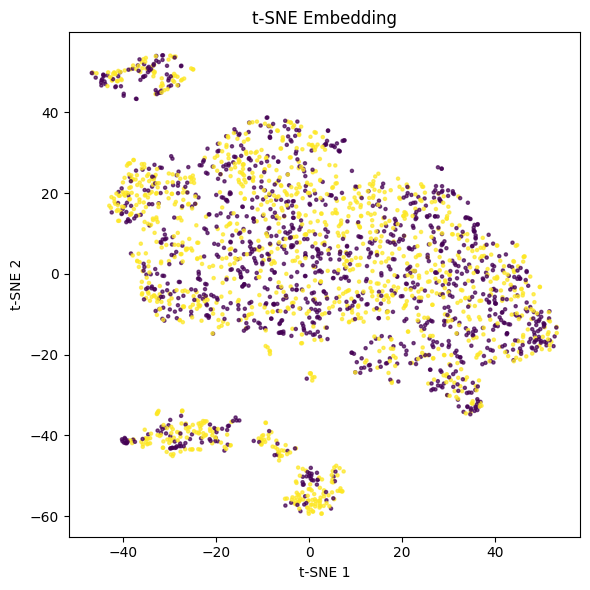

In [27]:
mask_1 = train_labels == 1
all_embeds_train = train_embeds[mask_1]
all_labels_train = train_labels[mask_1]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_2d = tsne.fit_transform(train_embeds)

plt.figure(figsize=(6, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    s=5,
    c=train_labels,
    alpha=0.7
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Embedding")
plt.tight_layout()
plt.show()

/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


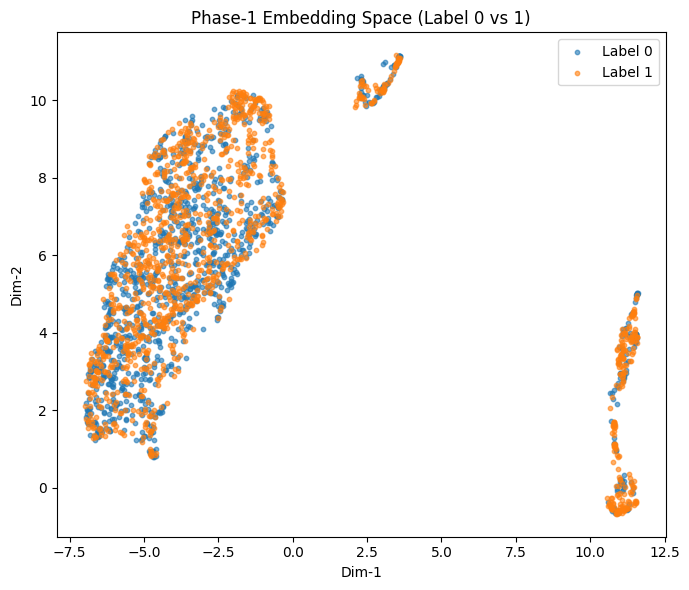

In [28]:
mask_0 = train_labels == 0
mask_1 = train_labels == 1

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=80
)
emb_2d = reducer.fit_transform(train_embeds)

plt.figure(figsize=(7, 6))
plt.scatter(emb_2d[mask_0, 0], emb_2d[mask_0, 1], s=10, alpha=0.6, label="Label 0")
plt.scatter(emb_2d[mask_1, 0], emb_2d[mask_1, 1], s=10, alpha=0.6, label="Label 1")
plt.legend()
plt.title("Phase-1 Embedding Space (Label 0 vs 1)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.tight_layout()
plt.show()

In [26]:
len(train_embeds)

2496

In [13]:
mask_1

array([False, False, False, ..., False, False, False])

In [ ]:
wav_transform = lambda wav: torch.tensor(
                    np.log(librosa.feature.melspectrogram(
                        y=wav.numpy() if isinstance(wav, torch.Tensor) else wav,
                        sr=hps.data.sampling_rate,
                        n_mels=hps.data.n_mel_channels,
                        n_fft=hps.data.filter_length,
                        hop_length=hps.data.hop_length,
                        win_length=hps.data.win_length,
                    ) + 1e-6),
                    dtype=torch.float32,
                )

Text(0.5, 1.0, 'Reconstructed (Clean)')

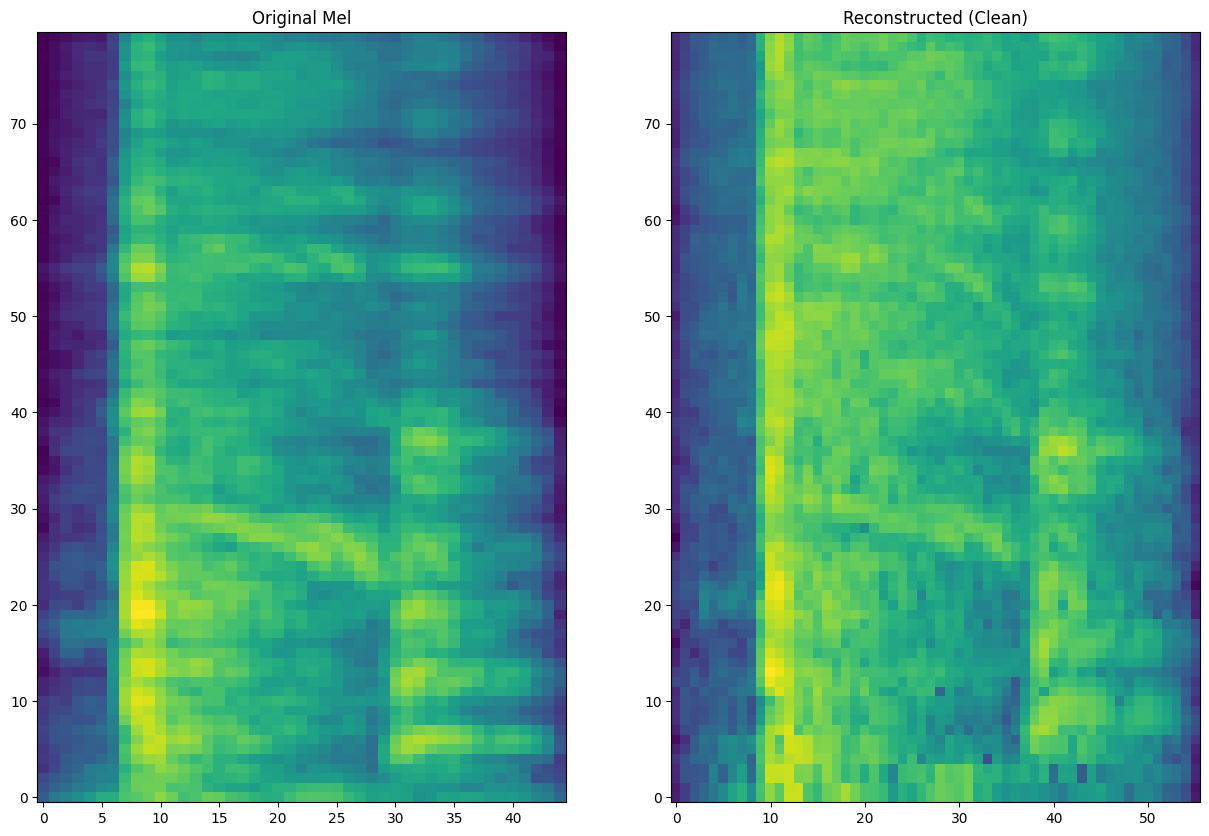

In [83]:
input_mel = wav_transform(audio[0].cpu())

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes[0].imshow(input_mel[0].cpu().numpy(), aspect='auto', origin='lower')
axes[0].set_title('Original Mel')
axes[1].imshow(reconstructed_mel[0].cpu().numpy(), aspect='auto', origin='lower')
axes[1].set_title('Reconstructed (Clean)')

In [89]:
mel_ouput = reconstructed_mel[0].cpu().numpy()
mel_ouput = np.exp(mel_ouput)

stft_mag = librosa.feature.inverse.mel_to_stft(
    mel_ouput,
    sr=16000,
    n_fft=2048,
    power=1.0
)

wav = librosa.griffinlim(
    stft_mag,
    n_iter=60,
    hop_length=200,
    win_length=800
)

Audio(wav, rate=16000)

In [86]:
mel_ouput = input_mel[0].cpu().numpy()
mel_ouput = np.exp(mel_ouput)

stft_mag = librosa.feature.inverse.mel_to_stft(
    mel_ouput,
    sr=16000,
    n_fft=2048,
    power=1.0
)

wav = librosa.griffinlim(
    stft_mag,
    n_iter=60,
    hop_length=200,
    win_length=800
)

Audio(wav, rate=16000)